### **Thông tin tổng quan**
Bộ dữ liệu 1.USA.gov Bitly được thu thập vào năm 2011 thông qua sự hợp tác giữa dịch vụ rút gọn URL Bitly và trang web chính phủ Mỹ USA.gov.
Khi người dùng truy cập các liên kết rút gọn có đuôi .gov hoặc .mil, hệ thống Bitly sẽ tự động ghi nhận một số thông tin ẩn danh (không chứa dữ liệu cá nhân).

Dữ liệu được lưu dưới dạng tệp văn bản, trong đó mỗi dòng là một đối tượng JSON. Bộ dữ liệu này thường được sử dụng trong các ví dụ phân tích dữ liệu thực hành vì:

- Nó phản ánh hành vi truy cập thực tế của người dùng trên Internet,

- Có cấu trúc đơn giản nhưng đa dạng biến,

- Dễ xử lý bằng Python và các thư viện như pandas, numpy.

Ý nghĩa của các biến
| Tên biến                    | Kiểu dữ liệu      | Ý nghĩa                                                                                                                                                | Ví dụ                                                    |
| --------------------------- | ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------- |
| `a` (User-Agent)            | *string*          | Thông tin về trình duyệt và hệ điều hành của người dùng truy cập liên kết. Dữ liệu này giúp phân loại người dùng theo nền tảng (Windows, Mac, Linux…). | `"Mozilla/5.0 (Windows NT 6.1; WOW64)"`                  |
| `tz` (Time Zone)            | *string* / *null* | Múi giờ địa lý mà người dùng truy cập (theo chuẩn IANA). Dữ liệu này hỗ trợ phân tích vị trí địa lý và thời điểm hoạt động.                            | `"America/New_York"`, `"Europe/London"`, `""`, `null`    |
| `r` (Referrer)              | *string*          | URL nguồn mà người dùng click để đến liên kết rút gọn. Giúp xác định kênh giới thiệu.                                                                  | `"http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf"` |
| `u` (Target URL)            | *string*          | URL gốc mà liên kết rút gọn trỏ đến.                                                                                                                   | `"http://www.ncbi.nlm.nih.gov/pubmed/22415991"`          |
| `c` (Country Code)          | *string*          | Mã quốc gia của người truy cập (theo chuẩn ISO).                                                                                                       | `"US"`                                                   |
| `cy` (City)                 | *string*          | Tên thành phố truy cập.                                                                                                                                | `"Danvers"`                                              |
| `gr` (State/Region Code)    | *string*          | Mã tiểu bang hoặc vùng của người dùng.                                                                                                                 | `"MA"`                                                   |
| `ll` (Latitude & Longitude) | *array of float*  | Tọa độ địa lý (vĩ độ, kinh độ) của người dùng truy cập.                                                                                                | `[42.576698, -70.954903]`                                |
| `nk` (Click Count)          | *int*             | Số lượt click vào liên kết.                                                                                                                            | `1`                                                      |
| `t` (Timestamp)             | *int*             | Thời gian truy cập tính theo Unix timestamp.                                                                                                           | `1331923247`                                             |
| `hc` (Hash Created Time)    | *int*             | Thời điểm liên kết được tạo (Unix timestamp).                                                                                                          | `1331822918`                                             |
| `hh` (Short Domain)         | *string*          | Tên miền rút gọn, thường là `1.usa.gov`.                                                                                                               | `"1.usa.gov"`                                            |
| `g` / `h` / `l`             | *string*          | Các mã hash nội bộ Bitly — giúp định danh liên kết.                                                                                                    | `"A6qOVH"`, `"wfLQtf"`, `"orofrog"`                      |


### **1. Chuẩn bị, đọc dữ liệu và tiền xử lý chung**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from datetime import datetime
from urllib.parse import urlparse


In [3]:
# 1. ĐỌC DỮ LIỆU TỪ FILE JSON TRUYỀN THỐNG (Mỗi dòng là một JSON object)

# Khởi tạo danh sách để chứa các bản ghi
records = [json.loads(line) for line in open("C:/Users/Admin/OneDrive/Documents/lab02/Lab02_Data_Analytics/Data Analysis Examples - Bitly & MovieLens/dataset/example.txt", encoding='utf-8')]

# Tạo DataFrame
df = pd.DataFrame(records)

# xem nhanh cấu trúc
print(df.shape)
print(df.columns)
df.head()

(3560, 18)
Index(['a', 'c', 'nk', 'tz', 'gr', 'g', 'h', 'l', 'al', 'hh', 'r', 'u', 't',
       'hc', 'cy', 'll', '_heartbeat_', 'kw'],
      dtype='object')


,a,c,nk,tz,gr,g,h,l,al,hh,r,u,t,hc,cy,ll,_heartbeat_,kw
0,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,1.0,America/New_York,MA,A6qOVH,wfLQtf,orofrog,"en-US,en;q=0.8",1.usa.gov,http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/...,http://www.ncbi.nlm.nih.gov/pubmed/22415991,1.331923e+09,1.331823e+09,Danvers,"[42.576698, -70.954903]",NaN,NaN
1,GoogleMaps/RochesterNY,US,0.0,America/Denver,UT,mwszkS,mwszkS,bitly,NaN,j.mp,http://www.AwareMap.com/,http://www.monroecounty.gov/etc/911/rss.php,1.331923e+09,1.308262e+09,Provo,"[40.218102, -111.613297]",NaN,NaN
2,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...,US,1.0,America/New_York,DC,xxr3Qb,xxr3Qb,bitly,en-US,1.usa.gov,http://t.co/03elZC4Q,http://boxer.senate.gov/en/press/releases/0316...,1.331923e+09,1.331920e+09,Washington,"[38.9007, -77.043098]",NaN,NaN
3,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_8)...,BR,0.0,America/Sao_Paulo,27,zCaLwp,zUtuOu,alelex88,pt-br,1.usa.gov,direct,http://apod.nasa.gov/apod/ap120312.html,1.331923e+09,1.331923e+09,Braz,"[-23.549999, -46.616699]",NaN,NaN
4,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,0.0,America/New_York,MA,9b6kNl,9b6kNl,bitly,"en-US,en;q=0.8",bit.ly,http://www.shrewsbury-ma.gov/selco/,http://www.shrewsbury-ma.gov/egov/gallery/1341...,1.331923e+09,1.273672e+09,Shrewsbury,"[42.286499, -71.714699]",NaN,NaN


### **2. Làm sạch dữ liệu cơ bản**

In [4]:
# 2.1 Chuẩn hóa tz: chuyển NaN/None/'' thành 'Unknown'
df['tz'] = df.get('tz').fillna('Unknown').replace('', 'Unknown')

# 2.2 Country: chuyển NaN thành 'Unknown'
df['c'] = df.get('c').fillna('Unknown').replace('', 'Unknown')

# 2.3 City (cy) và state (gr)
df['cy'] = df.get('cy').fillna('Unknown')
df['gr'] = df.get('gr').fillna('Unknown')

# 2.4 Thời gian: parse 't' và 'hc' nếu là chuỗi dạng RFC3339 / ISO
# Ví dụ value kiểu: "2012-02-08T03:05:05Z" hoặc "2012-02-08T03:05:05"
def parse_dt(x):
    try:
        return pd.to_datetime(x, utc=True)
    except Exception:
        return pd.NaT

df['t_ts'] = df.get('t').apply(parse_dt)
df['hc_ts'] = df.get('hc').apply(parse_dt)

### **3. Trích xuất thông tin từ a (User-Agent) và r (referrer)**

In [12]:
# 3.1: Hàm đơn giản để phát hiện hệ điều hành từ user-agent
def detect_os(ua):
    if not isinstance(ua, str) or ua.strip() == '':
        return 'Unknown'
    ua = ua.lower()
    if 'windows' in ua:
        return 'Windows'
    if 'mac os x' in ua or 'macintosh' in ua:
        return 'MacOS'
    if 'iphone' in ua or 'ipad' in ua or 'ios' in ua:
        return 'iOS'
    if 'android' in ua:
        return 'Android'
    if 'linux' in ua and 'android' not in ua:
        return 'Linux'
    return 'Other'

df['os'] = df.get('a').apply(detect_os)

# 3.2: referrer source (r) -> domain or social vs search vs direct
def ref_source(r):
    if not isinstance(r, str) or r.strip() == '':
        return 'direct'
    try:
        netloc = urlparse(r).netloc.lower()
    except:
        return 'other'
    # bỏ subdomain để lấy domain chính nếu cần
    if 'facebook.com' in netloc or 'fb.me' in netloc:
        return 'facebook'
    if 'twitter.com' in netloc or 't.co' in netloc:
        return 'twitter'
    if 'google.' in netloc or 'bing.com' in netloc or 'yahoo.' in netloc:
        return 'search'
    if 'reddit.com' in netloc:
        return 'reddit'
    if netloc == '':
        return 'direct'
    # nếu là .gov hoặc .mil
    if netloc.endswith('.gov') or netloc.endswith('.mil'):
        return 'gov'
    return 'other'

df['ref_domain'] = df.get('r').apply(lambda x: urlparse(x).netloc.lower() if isinstance(x, str) and x!='' else '')
df['ref_source'] = df.get('r').apply(ref_source)


### **4. Phân tích mô tả**

### **4.1. Các múi giờ (tz) nào có số lượt truy cập cao nhất**

tz
America/New_York        1251
Unknown                  641
America/Chicago          400
America/Los_Angeles      382
America/Denver           191
Europe/London             74
Asia/Tokyo                37
Pacific/Honolulu          36
Europe/Madrid             35
America/Sao_Paulo         33
Europe/Berlin             28
Europe/Rome               27
America/Rainy_River       25
Europe/Amsterdam          22
America/Phoenix           20
America/Indianapolis      20
Europe/Warsaw             16
America/Mexico_City       15
Europe/Paris              14
Europe/Stockholm          14
Name: count, dtype: int64


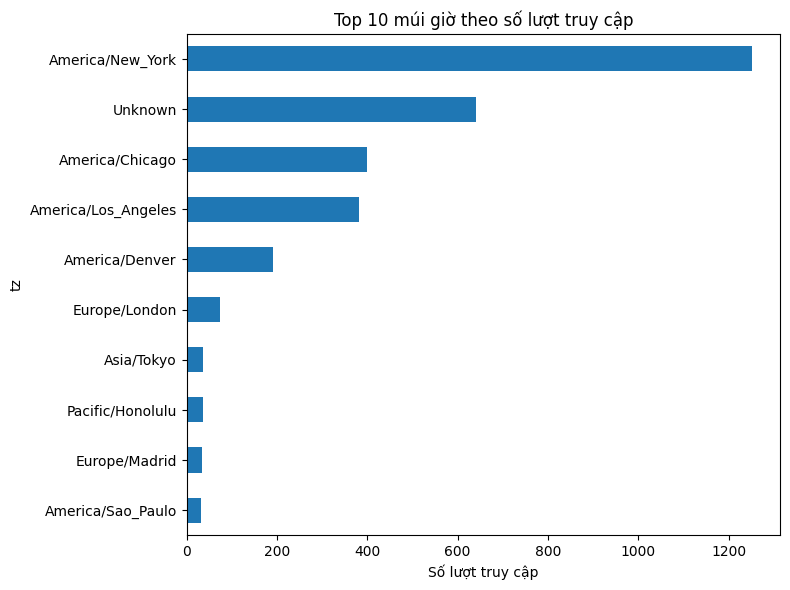

In [13]:
tz_counts = df['tz'].value_counts(dropna=False)
print(tz_counts.head(20))
# Biểu đồ top 10 tz
tz_counts.head(10).sort_values().plot.barh(figsize=(8,6))
plt.xlabel('Số lượt truy cập')
plt.title('Top 10 múi giờ theo số lượt truy cập')
plt.tight_layout()
plt.show()


### **Nhận xét**

Biểu đồ cho thấy lượng truy cập tập trung chủ yếu tại múi giờ America/New_York với hơn 1.200 lượt, chiếm tỷ trọng lớn nhất. Tiếp theo là Unknown, cho thấy có nhiều truy cập không xác định được vị trí. Các múi giờ khác như America/Chicago và America/Los_Angeles có lượng truy cập trung bình, trong khi các múi giờ ngoài Hoa Kỳ như Europe/London hay Asia/Tokyo có số lượt truy cập thấp.

### **4.2.Số người dùng thiếu thông tin múi giờ hoặc quốc gia**

Total rows: 3560
Missing tz: 641 (18.01%)
Missing country: 641 (18.01%)


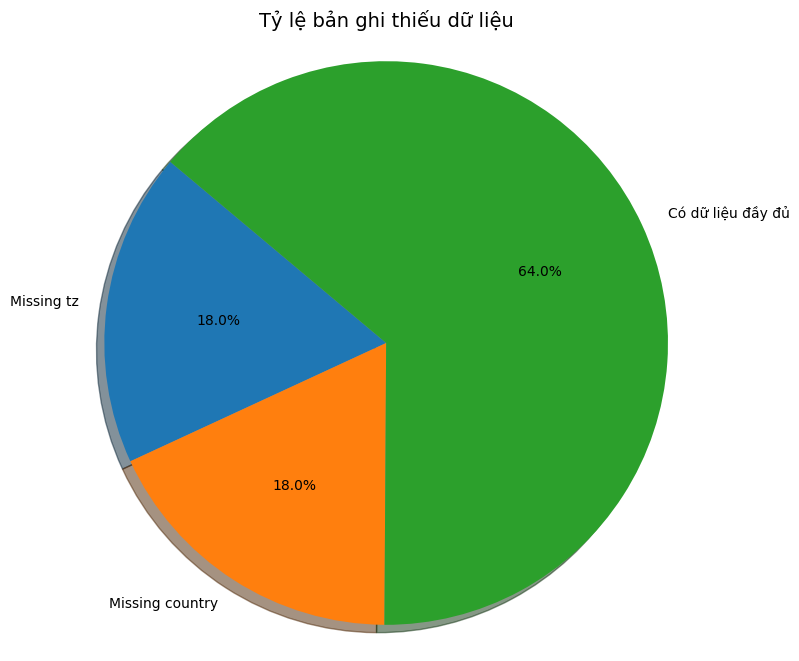

In [14]:
missing_tz = (df['tz']=='Unknown').sum()
missing_country = (df['c']=='Unknown').sum()
total = len(df)
print(f"Total rows: {total}")
print(f"Missing tz: {missing_tz} ({missing_tz/total:.2%})")
print(f"Missing country: {missing_country} ({missing_country/total:.2%})")

missing_dict = {
    'Missing tz': missing_tz,
    'Missing country': missing_country,
    'Có dữ liệu đầy đủ': total - missing_tz - missing_country  # phần còn lại
}

plt.figure(figsize=(8, 8))
plt.pie(
    missing_dict.values(),
    labels=missing_dict.keys(),
    autopct='%1.1f%%',
    startangle=140,
    shadow=True
)
plt.title('Tỷ lệ bản ghi thiếu dữ liệu', fontsize=14)
plt.axis('equal')  # đảm bảo hình tròn
plt.show()



### **Nhận xét**
Phần lớn các bản ghi có dữ liệu đầy đủ, chiếm 64% tổng số. Trong khi đó, 18% bản ghi thiếu thông tin về múi giờ (Missing tz) và 18% khác thiếu thông tin về quốc gia (Missing country).

### **4.3. Những nguồn referrer (r) phổ biến nhất**

ref_source
direct      1705
twitter      706
facebook     548
other        382
gov          160
search        59
Name: count, dtype: int64


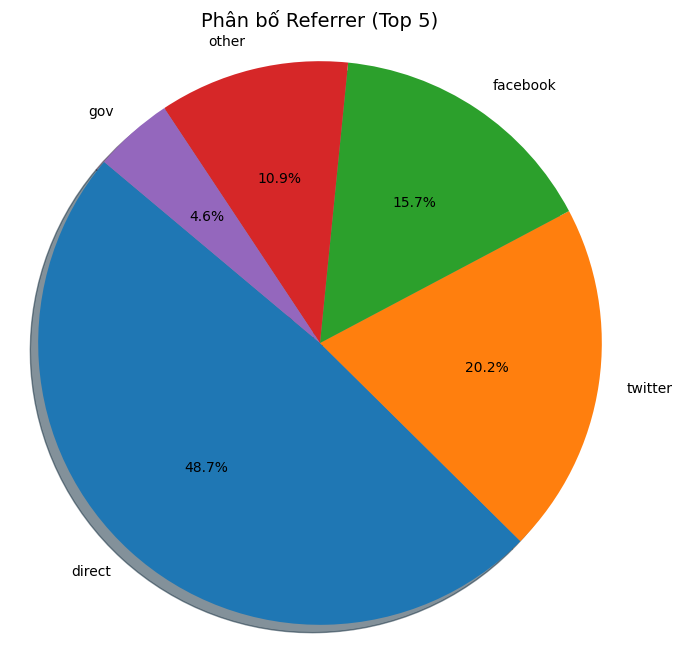

In [15]:
import matplotlib.pyplot as plt

# Đếm tần suất ref_source
ref_top = df['ref_source'].value_counts()
print(ref_top)

# Lấy Top 5 để biểu đồ gọn (có thể tăng giảm tùy ý)
ref_top_5 = ref_top.head(5)

# Vẽ biểu đồ tròn
plt.figure(figsize=(8, 8))
plt.pie(
    ref_top_5,
    labels=ref_top_5.index,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True
)
plt.title('Phân bố Referrer (Top 5)', fontsize=14)
plt.axis('equal')  # Đảm bảo hình tròn
plt.show()

### **Nhận xét**

Biểu đồ thể hiện cơ cấu phân bố các nguồn truy cập (Referrer) của người dùng. Trong đó, nhóm truy cập trực tiếp (direct) chiếm tỷ lệ cao nhất với 48,7%, cho thấy phần lớn người dùng chủ động tìm đến trang web, phản ánh mức độ nhận diện và uy tín thương hiệu khá tốt. Tiếp theo là Twitter với 20,2% và Facebook với 15,7%, chứng tỏ mạng xã hội vẫn đóng vai trò quan trọng trong việc thu hút người dùng. Bên cạnh đó, nhóm other chiếm 10,9%, thể hiện sự đa dạng về nguồn truy cập khác ngoài các kênh chính, trong khi gov chỉ chiếm 4,6%, cho thấy mức độ giới thiệu từ các trang thuộc chính phủ còn hạn chế. Nhìn chung, dữ liệu cho thấy xu hướng truy cập trực tiếp chiếm ưu thế, đồng thời các nền tảng mạng xã hội vẫn giữ vai trò đáng kể trong việc lan tỏa và dẫn dắt người dùng đến trang web.

### **5. Phân tích tương quan**

### **5.1 Thiết bị**

### **5.1.1 Tỷ lệ người dùng Windows vs Non-Windows**

In [16]:
os_counts = df['os'].value_counts()
print(os_counts)
windows_pct = os_counts.get('Windows', 0) / os_counts.sum()
non_windows_pct = 1 - windows_pct
print(f"Windows: {windows_pct:.2%}, Non-Windows: {non_windows_pct:.2%}")

os
Windows    2246
MacOS       771
Other       256
Android     131
Unknown     120
Linux        36
Name: count, dtype: int64
Windows: 63.09%, Non-Windows: 36.91%


### **Nhận xét**
Kết quả cho thấy Windows chiếm 63,09%, là hệ điều hành phổ biến nhất. Nhóm Non-Windows chiếm 36,91%, trong đó MacOS đứng thứ hai. Điều này cho thấy Windows vẫn giữ vai trò chủ đạo, còn các hệ điều hành khác chỉ chiếm tỷ lệ nhỏ hơn.

### **5.1.2 Phân bố hệ điều hành khác nhau theo múi giờ**

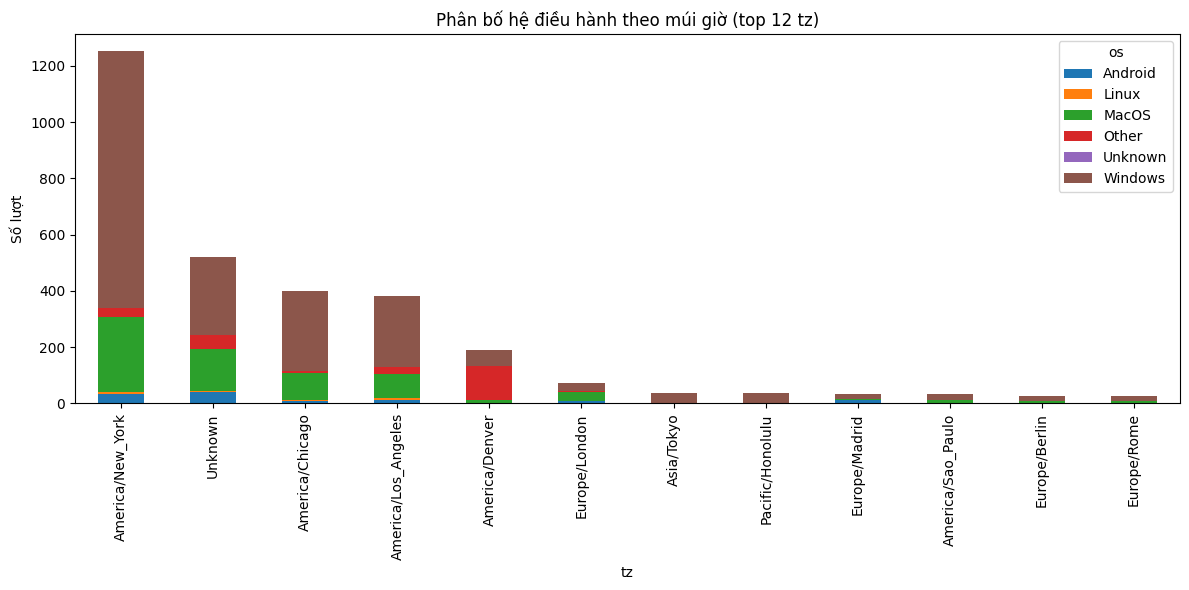

In [17]:
os_by_tz = df.pivot_table(index='tz', columns='os', values='t', aggfunc='count', fill_value=0)
# Lấy top tz theo tổng lượt để hiển thị
top_tz = tz_counts.head(12).index
os_by_tz.loc[top_tz].plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Phân bố hệ điều hành theo múi giờ (top 12 tz)")
plt.ylabel("Số lượt")
plt.tight_layout()
plt.show()


### **Nhận xét**
Biểu đồ cho thấy sự phân bố hệ điều hành theo múi giờ. Trong đó, America/New_York có số lượt sử dụng cao nhất, vượt trội so với các múi giờ khác. Các múi giờ như Unknown, America/Chicago và America/Los_Angeles cũng có số lượng đáng kể, nhưng thấp hơn nhiều. Hầu hết các múi giờ đều có Windows chiếm ưu thế, tiếp theo là MacOS, trong khi các hệ điều hành khác như Android, Linux hay Other chỉ chiếm tỷ lệ nhỏ.
Nhìn chung, biểu đồ phản ánh rằng người dùng chủ yếu tập trung tại khu vực Bắc Mỹ, đặc biệt là múi giờ America/New_York, và Windows vẫn là hệ điều hành phổ biến nhất trên hầu hết các vùng.

### **5.1.3 East Coast vs West Coast — phân vùng nhanh theo state**

coast
East       1319
Other       966
Unknown     641
West        634
Name: count, dtype: int64
os        Android     Linux     MacOS     Other   Unknown   Windows
coast                                                              
East     0.030326  0.005307  0.216073  0.024261  0.000000  0.724033
Other    0.035197  0.020704  0.245342  0.025880  0.000000  0.672878
Unknown  0.065523  0.001560  0.237129  0.078003  0.187207  0.430577
West     0.023659  0.012618  0.152997  0.235016  0.000000  0.575710


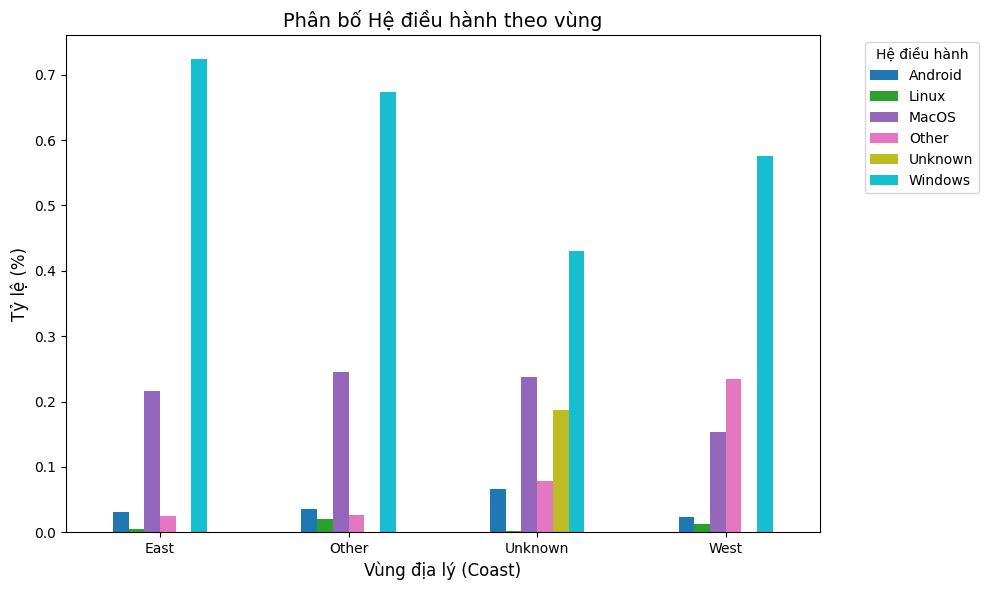

In [18]:
east_states = {'ME','NH','VT','MA','RI','CT','NY','NJ','PA','DE','MD','DC','VA','NC','SC','GA','FL','WV','OH','MI','IN','KY','TN','AL','MS'}  # mở rộng nếu cần
west_states = {'WA','OR','CA','NV','ID','MT','WY','UT','CO','AZ','NM','AK','HI'}

def coast_region(state):
    if not isinstance(state, str) or state=='Unknown':
        return 'Unknown'
    s = state.strip().upper()
    if s in east_states:
        return 'East'
    if s in west_states:
        return 'West'
    return 'Other'

df['coast'] = df['gr'].apply(coast_region)
coast_counts = df['coast'].value_counts()
print(coast_counts)
# So sánh Windows % theo coast
coast_os = df.groupby('coast')['os'].value_counts(normalize=True).unstack(fill_value=0)
print(coast_os)

ax = coast_os.plot(
    kind='bar',
    stacked=False,
    figsize=(10, 6),
    colormap='tab10'
)

plt.title('Phân bố Hệ điều hành theo vùng', fontsize=14)
plt.xlabel('Vùng địa lý (Coast)', fontsize=12)
plt.ylabel('Tỷ lệ (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Hệ điều hành', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



### **Nhận xét**
Biểu đồ thể hiện tỷ lệ sử dụng các hệ điều hành theo vùng địa lý. Trong đó, Windows chiếm ưu thế tuyệt đối ở tất cả các vùng, đặc biệt là khu vực East và Other, với tỷ lệ lần lượt khoảng trên 70% và gần 70%. MacOS đứng thứ hai, phổ biến ở hầu hết các vùng, trong khi Other và Unknown chỉ chiếm tỷ lệ nhỏ. Các hệ điều hành Android và Linux có mức sử dụng rất thấp, gần như không đáng kể.

Nhìn chung, dữ liệu cho thấy Windows vẫn là nền tảng chủ đạo trên mọi vùng, còn MacOS là lựa chọn phổ biến thứ hai, phản ánh sự thống trị của hai hệ điều hành này trong cơ cấu người dùng.

### **5.2 Khung hành vi thời gian**

### **5.2.1  Khung giờ có lượng truy cập cao nhất**

0   1970-01-01 00:00:01.331923247+00:00
1   1970-01-01 00:00:01.331923249+00:00
2   1970-01-01 00:00:01.331923250+00:00
3   1970-01-01 00:00:01.331923249+00:00
4   1970-01-01 00:00:01.331923251+00:00
Name: t_ts, dtype: datetime64[ns, UTC]
hour_utc
0.0    3440
Name: count, dtype: int64


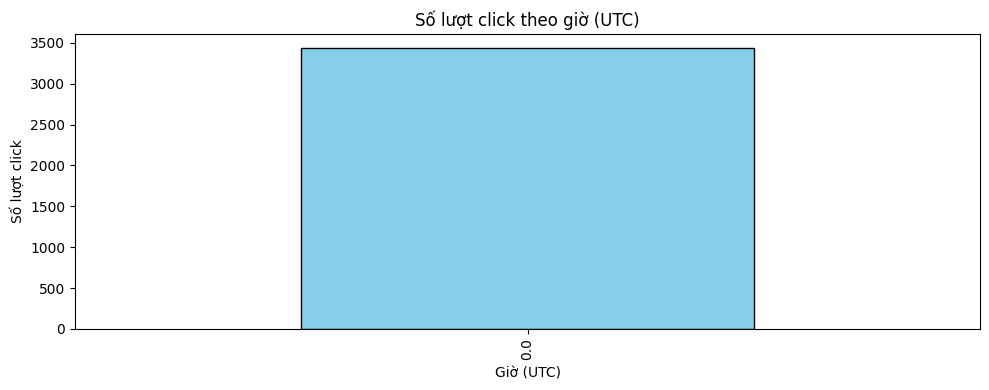

In [19]:
# Đảm bảo cột t_ts có kiểu datetime
df['t_ts'] = pd.to_datetime(df['t'], errors='coerce', utc=True)

# Kiểm tra 5 giá trị đầu tiên
print(df['t_ts'].head())

# Trích xuất giờ UTC
df['hour_utc'] = df['t_ts'].dt.hour

# Kiểm tra phân bố giờ
print(df['hour_utc'].value_counts().sort_index())

# Vẽ lại biểu đồ
hour_counts = df['hour_utc'].value_counts().sort_index()
hour_counts.plot(kind='bar', figsize=(10,4), color='skyblue', edgecolor='black')
plt.xlabel('Giờ (UTC)')
plt.ylabel('Số lượt click')
plt.title('Số lượt click theo giờ (UTC)')
plt.tight_layout()
plt.show()



### **Nhận xét**

Biểu đồ cho thấy toàn bộ lượt click tập trung tại một mốc giờ duy nhất (0 giờ UTC), với tổng số khoảng 3.400 lượt. Điều này cho thấy dữ liệu chưa có sự phân bố theo thời gian hoặc có khả năng các giá trị thời gian bị ghi nhận trùng lặp.

### **5.2.2 Mối tương quan giữa thời điểm tạo link (hc) và thời điểm click (t)**

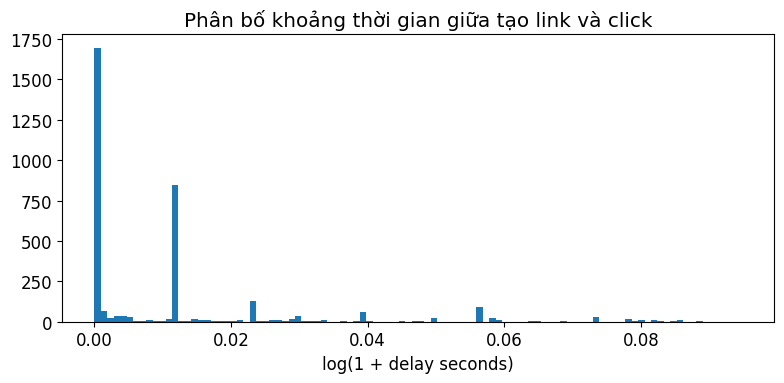

Correlation giữa số link tạo theo ngày và số click theo cùng ngày: nan


c:\python\Lib\site-packages\numpy\lib\_function_base_impl.py:2991: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\python\Lib\site-packages\numpy\lib\_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\python\Lib\site-packages\numpy\lib\_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [35]:
df['delay_seconds'] = (df['t_ts'] - df['hc_ts']).dt.total_seconds()
# loại bỏ delay âm hoặc quá lớn nếu là outlier
delay = df['delay_seconds'].dropna()
delay.describe()
# histogram (log scale vì phân bố có thể rất lệch)
plt.figure(figsize=(8,4))
plt.hist(np.log1p(delay[delay>0]), bins=100)
plt.xlabel('log(1 + delay seconds)')
plt.title('Phân bố khoảng thời gian giữa tạo link và click')
plt.tight_layout()
plt.show()

# kiểm tra correlation giữa hc_ts và t_ts (theo ngày)
df['hc_date'] = df['hc_ts'].dt.date
df['t_date'] = df['t_ts'].dt.date
# số lượng click theo ngày tạo link
counts_by_hcdate = df.groupby('hc_date').size()
counts_by_tdate = df.groupby('t_date').size()
# correlation (chỉ trên các ngày có cả hai)
common_idx = counts_by_hcdate.index.intersection(counts_by_tdate.index)
corr = counts_by_hcdate.loc[common_idx].corr(counts_by_tdate.loc[common_idx])
print("Correlation giữa số link tạo theo ngày và số click theo cùng ngày:", corr)


### **Nhận xét**

Biểu đồ cho thấy phần lớn các lượt click xảy ra gần như ngay sau khi tạo link, thể hiện qua mật độ cao tập trung ở vùng log(1 + delay seconds) gần 0. Số lượng trường hợp có độ trễ lớn hơn giảm mạnh và phân tán thưa dần về bên phải.

### **5.3 Địa lý**

### **5.3.1 Những bang (gr) và thành phố (cy) có lượng truy cập lớn nhất**

gr
Unknown    641
CA         279
NY         204
TX         140
UT         133
MA         121
FL         118
GA         108
VA         108
DC          98
MD          95
PA          86
NJ          77
WA          75
IL          61
07          56
OH          48
NC          46
MI          40
CO          39
Name: count, dtype: int64
cy
Unknown          641
Provo            121
White Plains     104
Washington        98
Palo Alto         68
Shrewsbury        46
Acworth           38
Dallas            33
Paramus           32
Nogata            29
Los Angeles       28
Seattle           26
Philadelphia      26
Alexandria        24
Chicago           24
New York          21
Mountain View     21
Brooklyn          20
Westborough       18
Honolulu          18
Name: count, dtype: int64


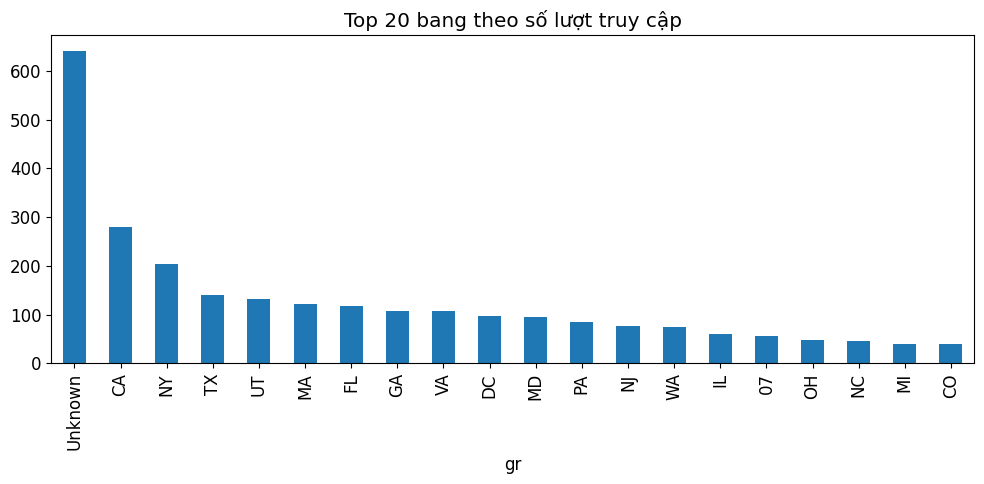

In [36]:
state_counts = df['gr'].value_counts().head(20)
city_counts = df['cy'].value_counts().head(20)
print(state_counts)
print(city_counts)

# Bar plot
state_counts.plot.bar(figsize=(10,5))
plt.title('Top 20 bang theo số lượt truy cập')
plt.tight_layout()
plt.show()


### **Nhận xét**

Biểu đồ cho thấy bang có số lượt truy cập cao nhất là “Unknown”, chiếm tỷ trọng lớn nhất, cho thấy một phần đáng kể dữ liệu không xác định được vị trí địa lý. Trong số các bang có thông tin, California (CA), New York (NY) và Texas (TX) là ba bang có lượng truy cập cao nhất, phản ánh mức độ hoạt động mạng mạnh tại các khu vực đông dân và phát triển.

### **5.3.2 Người dùng từ ngoài nước Mỹ (c != 'US') chiếm bao nhiêu phần trăm**

Non-US: 1255 (35.25%), Unknown country: 641 (18.01%)
c
US         0.647472
Unknown    0.180056
GB         0.020787
CA         0.016854
ES         0.010393
JP         0.010393
BR         0.009831
DE         0.007865
IT         0.007584
NL         0.006180
MX         0.005337
PL         0.004494
FR         0.003933
SE         0.003933
RU         0.003652
NZ         0.003090
PR         0.002809
HK         0.002809
FI         0.002809
CZ         0.002809
Name: proportion, dtype: float64


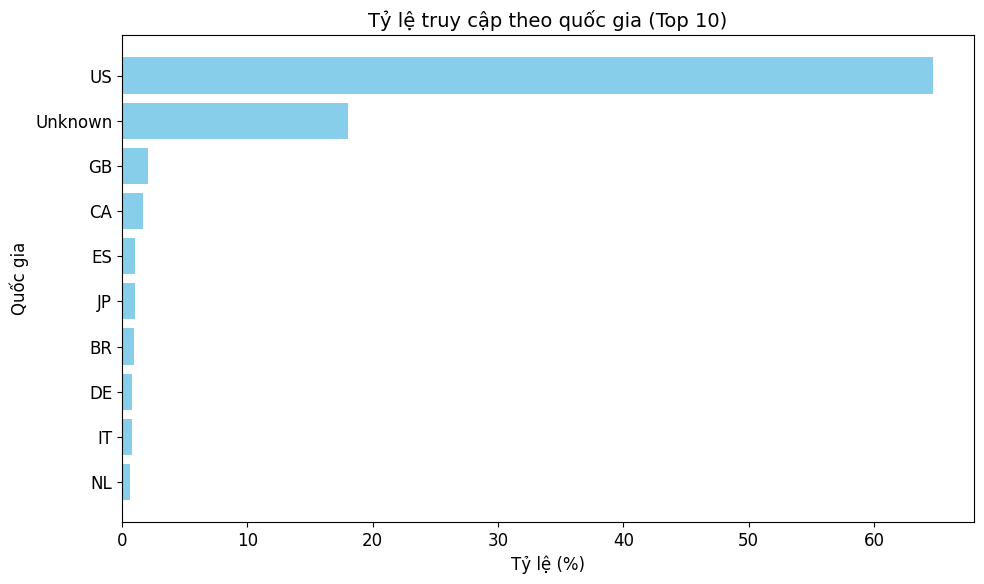

In [43]:
total = len(df)
non_us = (df['c'] != 'US').sum()
unknown_c = (df['c']=='Unknown').sum()
print(f"Non-US: {non_us} ({non_us/total:.2%}), Unknown country: {unknown_c} ({unknown_c/total:.2%})")
# tỉ lệ theo quốc gia
country_pct = df['c'].value_counts(normalize=True).head(20)
print(country_pct)

# Lấy top 10 quốc gia
country_pct = df['c'].value_counts(normalize=True).head(10)

plt.figure(figsize=(10, 6))
plt.barh(country_pct.index, country_pct.values * 100, color='skyblue')
plt.xlabel('Tỷ lệ (%)', fontsize=12)
plt.ylabel('Quốc gia', fontsize=12)
plt.title('Tỷ lệ truy cập theo quốc gia (Top 10)', fontsize=14)
plt.gca().invert_yaxis()  # Đảo chiều để US ở trên cùng
plt.tight_layout()
plt.show()

### **Nhận xét**

Biểu đồ thể hiện tỷ lệ truy cập theo quốc gia, trong đó Hoa Kỳ (US) chiếm ưu thế tuyệt đối với hơn 60% tổng lượng truy cập, cho thấy phần lớn người dùng đến từ Mỹ. Tiếp theo là nhóm Unknown với khoảng 18%, phản ánh số lượng đáng kể các bản ghi không xác định được quốc gia. Các quốc gia còn lại như Anh (GB), Canada (CA), Tây Ban Nha (ES), Nhật Bản (JP) và một số nước châu Âu khác chỉ chiếm tỷ lệ rất nhỏ.

### **5.4 Nguồn truy cập**

### **5.4.1 Mạng xã hội nào chiếm tỉ lệ referrer cao nhất** 

In [38]:
ref_counts = df['ref_source'].value_counts(normalize=True)
print(ref_counts)  # in ra % các nguồn như facebook, twitter, search, direct, other

ref_source
direct      0.478933
twitter     0.198315
facebook    0.153933
other       0.107303
gov         0.044944
search      0.016573
Name: proportion, dtype: float64


### **5.4.2 Có sự khác biệt referrer theo hệ điều hành hoặc múi giờ không**

ref_source    direct  facebook       gov     other    search   twitter
os                                                                    
Android     0.213740  0.206107  0.015267  0.000000  0.000000  0.564885
Linux       0.361111  0.361111  0.027778  0.055556  0.111111  0.083333
MacOS       0.473411  0.134890  0.020752  0.035019  0.015564  0.320363
Other       0.371094  0.031250  0.000000  0.476562  0.000000  0.121094
Unknown          NaN       NaN       NaN       NaN       NaN       NaN
Windows     0.482636  0.176313  0.062778  0.102850  0.019145  0.156278


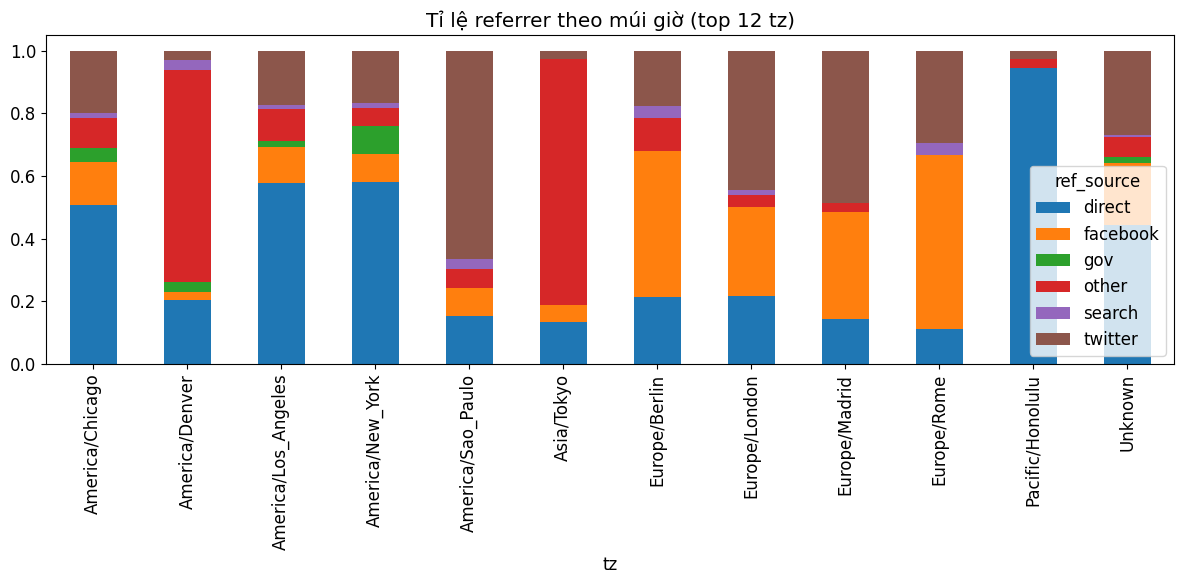

In [39]:
# Theo OS
ref_by_os = df.pivot_table(index='os', columns='ref_source', values='t', aggfunc='count', fill_value=0)
ref_by_os_norm = ref_by_os.div(ref_by_os.sum(axis=1), axis=0)
print(ref_by_os_norm)

# Theo tz (chỉ top tz để dễ nhìn)
top_tz = df['tz'].value_counts().head(12).index
ref_by_tz = df[df['tz'].isin(top_tz)].pivot_table(index='tz', columns='ref_source', values='t', aggfunc='count', fill_value=0)
ref_by_tz_norm = ref_by_tz.div(ref_by_tz.sum(axis=1), axis=0)
ref_by_tz_norm.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Tỉ lệ referrer theo múi giờ (top 12 tz)')
plt.tight_layout()
plt.show()


### **Nhận xét**

Biểu đồ thể hiện tỷ lệ nguồn truy cập (referrer) theo múi giờ, trong đó có thể nhận thấy sự đa dạng đáng kể giữa các khu vực địa lý.

Ở các múi giờ thuộc châu Mỹ như America/Los_Angeles, New_York và Chicago, nguồn truy cập trực tiếp (direct) chiếm ưu thế, cho thấy người dùng tại đây có xu hướng truy cập thẳng vào trang web thay vì qua mạng xã hội hay công cụ tìm kiếm. Ngược lại, ở châu Âu (như Berlin, London, Rome), Facebook và Twitter đóng vai trò lớn hơn, phản ánh mức độ tương tác xã hội cao.

Đáng chú ý, Asia/Tokyo và America/Denver có tỷ lệ nguồn “other” vượt trội, cho thấy khả năng tồn tại các kênh truy cập riêng biệt hoặc không phổ biến. Nhìn chung, dữ liệu cho thấy mỗi khu vực có đặc trưng riêng về hành vi truy cập, trong đó Mỹ và châu Âu vẫn là những khu vực có hoạt động nổi bật và đa kênh nhất.